## Download the required files and store them in a single directory

This catalog_path directory should contain: 
  1. The master catalog from https://cosmos2025.iap.fr/catalog.html
  2. The SCI Tarballs of all tiles at 30 mas pixel scale for the four NIRCam bands F115W, F150W, F277W, and F444W. https://cosmos2025.iap.fr/nircam.html#downloads

In [1]:
catalog_path = r"C:/Users/cputh/Documents/COSMOSWeb/"
master_catalog = 'COSMOSWeb_mastercatalog_v1.fits'

## Applying cuts to the master catalog

In [2]:
import os
import numpy as np
from astropy.table import Table
from astropy.nddata import Cutout2D
from astropy.io import fits

import tarfile
import gzip
import warnings

warnings.filterwarnings('ignore')

from lenstronomy.Util.param_util import ellipticity2phi_q

band_list = ["f115w", "f150w", "f277w", "f444w"]

In [ ]:
def process_catalog(master_catalog_path, max_z=None, faintest_apparent_mag=21, min_dist=85):
    """This function filters out sources in the catalog so that only
    galaxies with high SNR remain. Thus, we perform the following cuts:

    1. redshift < max_z if max_z is not None
    2. AB magnitude < faintest_apparent_mag in all of the following bands:
        F115W, F150W, F277W, F444W
    3. Remove galaxies with nearby contaminants (if distance < min_dist)

    :param master_catalog_path: path to the COSMOSWeb_mastercatalog_v1.fits file.
        This catalog can be downloaded from https://cosmos2025.iap.fr/catalog.html
    :type master_catalog_path: string
    :return: merged astropy table with only high SNR galaxies.
        This astropy table is the same as the one that comes with the catalog,
        but with some columns renamed for clarity, and extraneous columns removed.
    """

    photometry_table = Table.read(master_catalog_path, format="fits", hdu=1)

    sources_with_contaminants = find_sources_with_contaminants(photometry_table, min_dist)

    lephare_table = Table.read(master_catalog_path, format="fits", hdu=2)
    photometry_table, lephare_table = apply_cuts(photometry_table, lephare_table, max_z, faintest_apparent_mag, sources_with_contaminants)
    photometry_table = rewrite_and_discard_columns(photometry_table, lephare_table)

    return photometry_table

#-----------------------------------------------------------------------------------------------------------------------------

def find_sources_with_contaminants(photometry_table, min_dist):
    """Finds all sources that have a nearby contaminant (within min_dist pixels)."""

    sources_with_contaminants = []
    
    for tile in list(set(photometry_table['tile'])):
        tiled_table = photometry_table[photometry_table['tile'] == tile]
        x = tiled_table['x_image'].data
        y = tiled_table['y_image'].data

        # Compute pairwise distances N pairs at a time; very slow and inefficient
        # Can't use scipy's pdist due to memory issues (too many pairs)
        for i in range(len(tiled_table)):
            distances = np.sqrt((x - x[i])**2 + (y - y[i])**2)

            if np.any(np.delete(distances, i) < min_dist):
                id = tiled_table['id'][i]
                sources_with_contaminants.append(id)

    return np.array(sources_with_contaminants, dtype=np.int32)

#-----------------------------------------------------------------------------------------------------------------------------

def apply_cuts(photometry_table, lephare_table, max_z, faintest_apparent_mag, sources_with_contaminants):
    """This function filters out sources in the catalog so that only
    galaxies with high SNR remain. Thus, we perform the following cuts:


    1. redshift < max_z if max_z is not None
    2. AB magnitude < faintest_apparent_mag in all of the following bands:
        F115W, F150W, F277W, F444W
    3. Remove galaxies with nearby contaminants (if distance < min_dist)
    """
    is_ok = np.ones(len(lephare_table), dtype=bool)

    # filters out sources with artifacts/issues
    # see https://cosmos2025.iap.fr/catalog.html#quality-flags for warn_flag documentation
    is_ok &= photometry_table["warn_flag"].data == 0

    # redshift cut
    if max_z is not None:
        is_ok &= lephare_table["zfinal"].data < max_z

    # Some galaxies have their redshifts in the catalog set to -99
    # The documentation does not explain why; we filter these galaxies out
    is_ok &= lephare_table["zfinal"].data != -99

    # only includes galaxies
    # type = 0 is galaxies, type = 1 is stars, type = 2 is QSOs
    is_ok &= lephare_table["type"].data == 0

    # magnitude cuts: apparent magnitude < 21 in all of the following bands
    for band in [
        "mag_auto_f115w",
        "mag_auto_f150w",
        "mag_auto_f277w",
        "mag_auto_f444w",
    ]:
        is_ok &= photometry_table[band].data < faintest_apparent_mag

    # remove sources with nearby contaminants
    is_ok &= np.invert(np.isin(photometry_table['id'].data, sources_with_contaminants))

    photometry_table = photometry_table[is_ok]
    lephare_table = lephare_table[is_ok]

    return photometry_table, lephare_table

#-----------------------------------------------------------------------------------------------------------------------------

def rewrite_and_discard_columns(photometry_table, lephare_table):

    # The catalog has different ellipticity and angle conventions; we overwrite them here with the SLSim convention
    e1 = np.array(photometry_table["e1"], dtype=np.float64)
    e2 = np.array(photometry_table["e2"], dtype=np.float64)
    phi, q = ellipticity2phi_q(e1=e1, e2=e2)
    photometry_table["sersic_angle"] = phi
    photometry_table["axis_ratio"] = q

    # radius_sersic is the half-light radius along the major axis
    # convert it to the geometric mean of the major and minor axis lengths
    # also convert from degrees to arcseconds and rename
    photometry_table["radius_sersic"] = (
        np.sqrt(q) * photometry_table["radius_sersic"].data * 3600
    )
    photometry_table.rename_column("radius_sersic", "angular_size")

    photometry_table.rename_column("fmf_chi2", "sersic_fit_chi2")
    photometry_table.rename_column("sersic", "sersic_index")

    photometry_table["z"] = lephare_table["zfinal"]

    # drop extraneous data
    keep_columns = [
        "id",
        "sersic_index",  # sersic index n
        "axis_ratio",  # axis ratio q
        "sersic_angle",  # radians, measured from East to North
        "angular_size",  # half light radius (geometric mean) in arcseconds, obtained from the sersic fit
        "z", # redshift
        "sersic_fit_chi2", # chi2 of the sersic fit
        # -------------------------------------------------------------------------------
        # These will be deleted later
        "tile",
        "x_image",  # coordinates of the source on the detection image in units of pixels
        "y_image",  # coordinates of the source on the detection image in units of pixels
    ]

    for col in photometry_table.colnames:
        if col not in keep_columns:
            photometry_table.remove_column(col)

    return photometry_table

In [4]:
# This takes several minutes
processed_catalog = process_catalog(os.path.join(catalog_path, master_catalog))
print(len(processed_catalog))

2541


## Extract and save all cutout images in downselected catalog

The following tar files should be inside of your catalog_path directory:
1. mosaic_nircam_f115w_COSMOS-Web_30mas_all_v1.0_sci.tar.gz
2. mosaic_nircam_f150w_COSMOS-Web_30mas_all_v1.0_sci.tar.gz
3. mosaic_nircam_f277w_COSMOS-Web_30mas_all_v1.0_sci.tar.gz
4. mosaic_nircam_f444w_COSMOS-Web_30mas_all_v1.0_sci.tar.gz

Note: These .tar.gz extensions are misleading and the tar archives are not actually gzipped.

In [5]:
def extract_cutout_images(tile, cutout_size):

    images = {}

    # some images have the source located at the edge of the detector
    # keep track of them and we'll discard them at the end
    bad_id = []

    for band in band_list:

        tar_name = f"mosaic_nircam_{band}_COSMOS-Web_30mas_all_v1.0_sci.tar.gz"

        # Open the tarball
        with tarfile.open(os.path.join(catalog_path, tar_name), 'r') as tar:
        
            file_name = f"mosaic_nircam_{band}_COSMOS-Web_30mas_{tile}_v1.0_sci.fits.gz"
            # Open the FITS file as a file-like object
            with tar.extractfile(file_name) as fits_gz_file:
            
                # Decompress the file-like .gz object into a file
                with gzip.open(fits_gz_file) as fits_file:
                
                    hdul = fits.open(fits_file)
                    data = hdul[0].data     # 1.78 GB
                    hdul.close()

        for entry in processed_catalog[processed_catalog['tile'] == tile]:
            if entry['id'] in bad_id:
                continue

            if entry['id'] not in images:
                images[entry['id']] = {}

            coords = np.array([entry["x_image"], entry["y_image"]])
            image = Cutout2D(data, tuple(coords), cutout_size).data

            # some images are not centered at the source; we fix that here
            source_center = np.array(np.unravel_index(np.argmax(image), image.shape))[::-1]
            coords = coords + source_center - (cutout_size - 1) / 2
            image = Cutout2D(data, tuple(coords), cutout_size).data

            # checks if the source is located at the edge of the detector
            # the image will have a bunch of zeros
            if len(np.where(image == 0)[0]) > 100:
                bad_id.append(entry['id'])
                del images[entry['id']]
            else:
                images[entry['id']].update({band: image})
                
        # Frees up memory before the next iteration
        del data

    return images, bad_id

In [6]:
def delete_id_from_catalog(id_list, catalog):
    for id in id_list:
        catalog = catalog[catalog['id'] != id]

    return catalog

In [7]:
def save_cutout_images_to_fits(images, output_file_directory):
    for id in images.keys():
        hdu_list = []
        hdu_list.append(fits.PrimaryHDU())

        for band in band_list:
            hdu_list.append(fits.ImageHDU(data=images[id][band], name=band))

        output_filename = f"COSMOSWeb_galaxy_{id}_image.fits"
        output_file = os.path.join(output_file_directory, output_filename)
        
        hdu_list = fits.HDUList(hdu_list)
        hdu_list.writeto(output_file, overwrite=True)
        hdu_list.close()

Extract cutouts and save images one tile at a time to reduce RAM usage. This takes 30-45 minutes

In [8]:
output_file_directory = r"C:/Users/cputh/Documents/COSMOSWeb_galaxy_catalog/"

In [9]:
cutout_size = 121

for tile in ["A1", "A2", "A3", "A4", "A5", "A6", "A7", "A8", "A9", "A10", "B1", "B2", "B3", "B4", "B5", "B6", "B7", "B8", "B9", "B10"]:
    print(tile)
    
    images, bad_id = extract_cutout_images(tile=tile, cutout_size=cutout_size)
    processed_catalog = delete_id_from_catalog(bad_id, processed_catalog)
    save_cutout_images_to_fits(images=images, output_file_directory=output_file_directory)

    # Frees up memory before the next iteration
    del images

A1
A2
A3
A4
A5
A6
A7
A8
A9
A10
B1
B2
B3
B4
B5
B6
B7
B8
B9
B10


Save catalog as a fits file

In [10]:
output_file = os.path.join(output_file_directory, "COSMOSWeb_galaxy_catalog.fits")

delete_columns = [
    "tile",
    "x_image",
    "y_image",
]

for col in processed_catalog.colnames:
    if col in delete_columns:
        processed_catalog.remove_column(col)

processed_catalog.write(output_file, format='fits', overwrite=True)
processed_catalog

id,angular_size,sersic_index,sersic_fit_chi2,sersic_angle,axis_ratio,z
int64,float64,float64,float64,float64,float64,float64
5,1.8458296023057588,6.747353267873082,536.3488159179688,-0.7128673105442321,0.5895829878414183,0.6265
360,0.21349295107883176,2.610399486598715,234.08677673339844,1.4760131685397027,0.3113210237124925,0.35
361,0.6979463838774066,7.715222391914014,466.2574462890625,0.03495674935097482,0.8248926336139187,0.3499
759,0.3275453687275964,1.7591678089065328,351.1864929199219,-0.3649419596469989,0.3651109189263228,0.3296
780,0.3012568562924953,3.117995787906508,458.81512451171875,-0.7292512084217572,0.6351300359428074,0.3532
884,0.29055876362000066,2.8654582937048887,117.88330078125,0.25942241006587025,0.33021922816009924,0.3575
885,0.35023403920409796,1.0247371036474475,122.40618133544922,-0.6955707415431838,0.2170206548329478,0.3304
2187,0.5629541240890739,1.3726042003366874,191.96127319335938,1.005121418727866,0.24385470137572343,0.3195
2188,0.652882706436637,0.7527719619004107,217.07818603515625,0.1837765409985734,0.3340017621811943,0.3235


In [11]:
output_tar = r"C:/Users/cputh/Documents/COSMOSWeb_galaxy_catalog.tar.gz"

def save_catalog_as_tar(output_tar):
    with tarfile.open(output_tar, "w:gz") as tar:
        tar.add(output_file_directory, arcname=r"COSMOSWeb_galaxy_catalog/")

save_catalog_as_tar(output_tar)

## Montage of sources

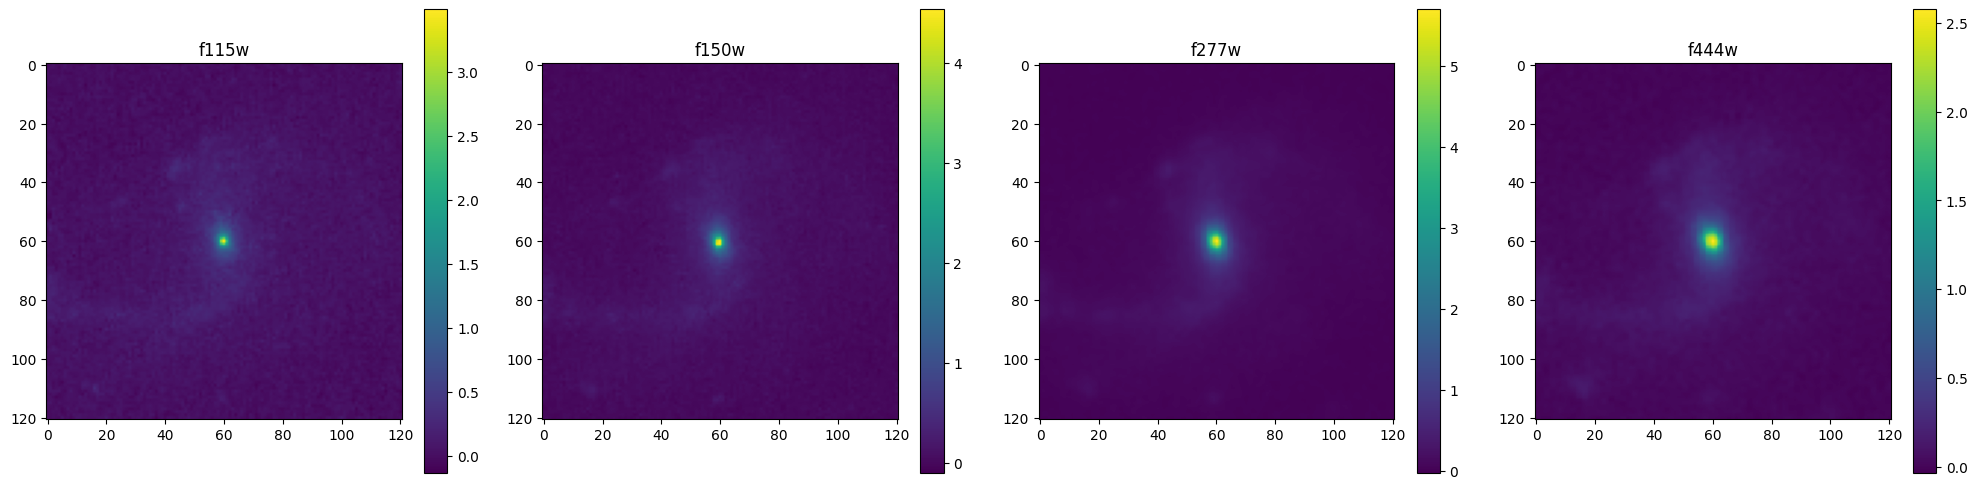

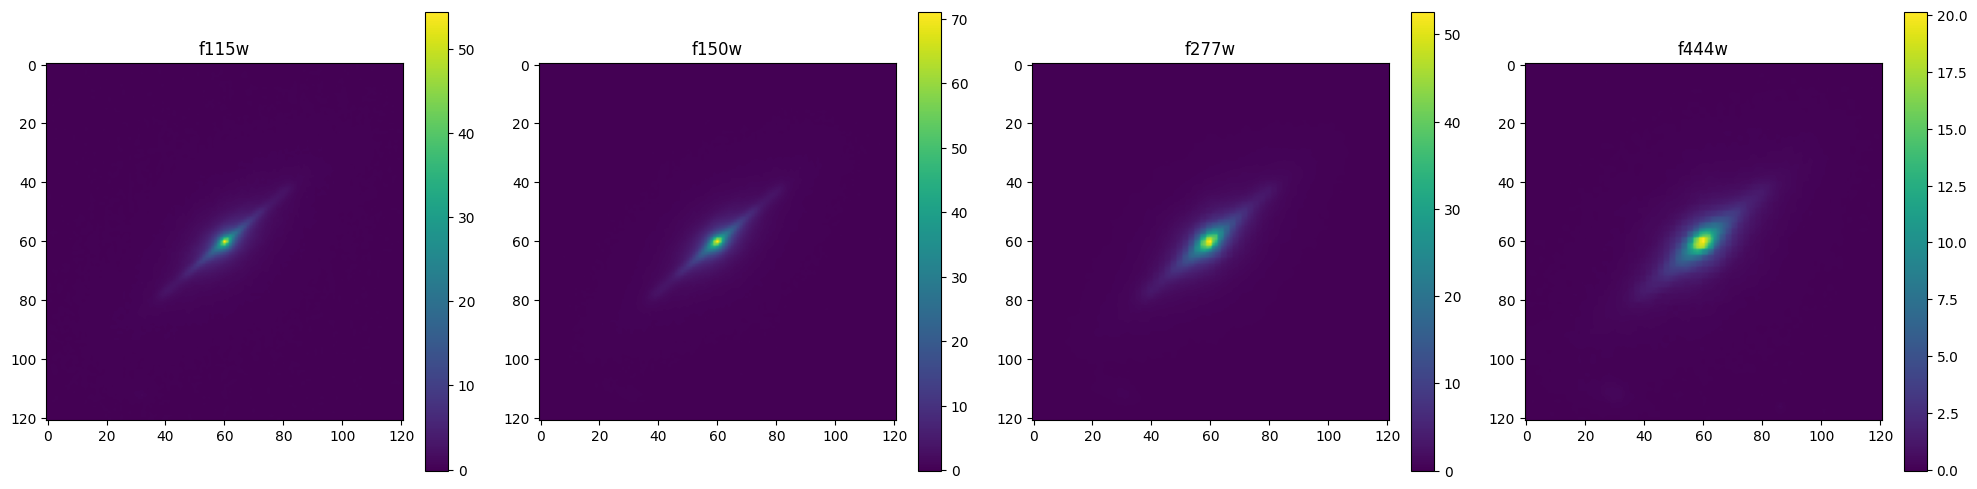

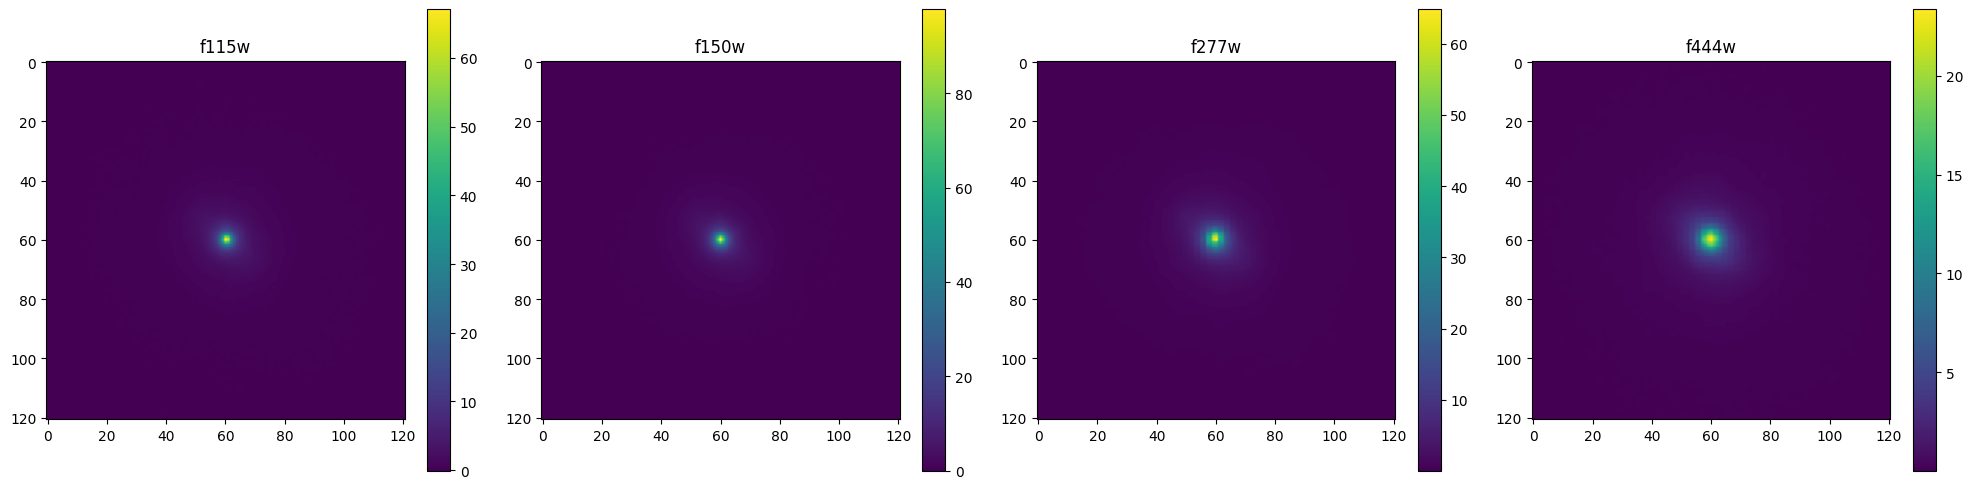

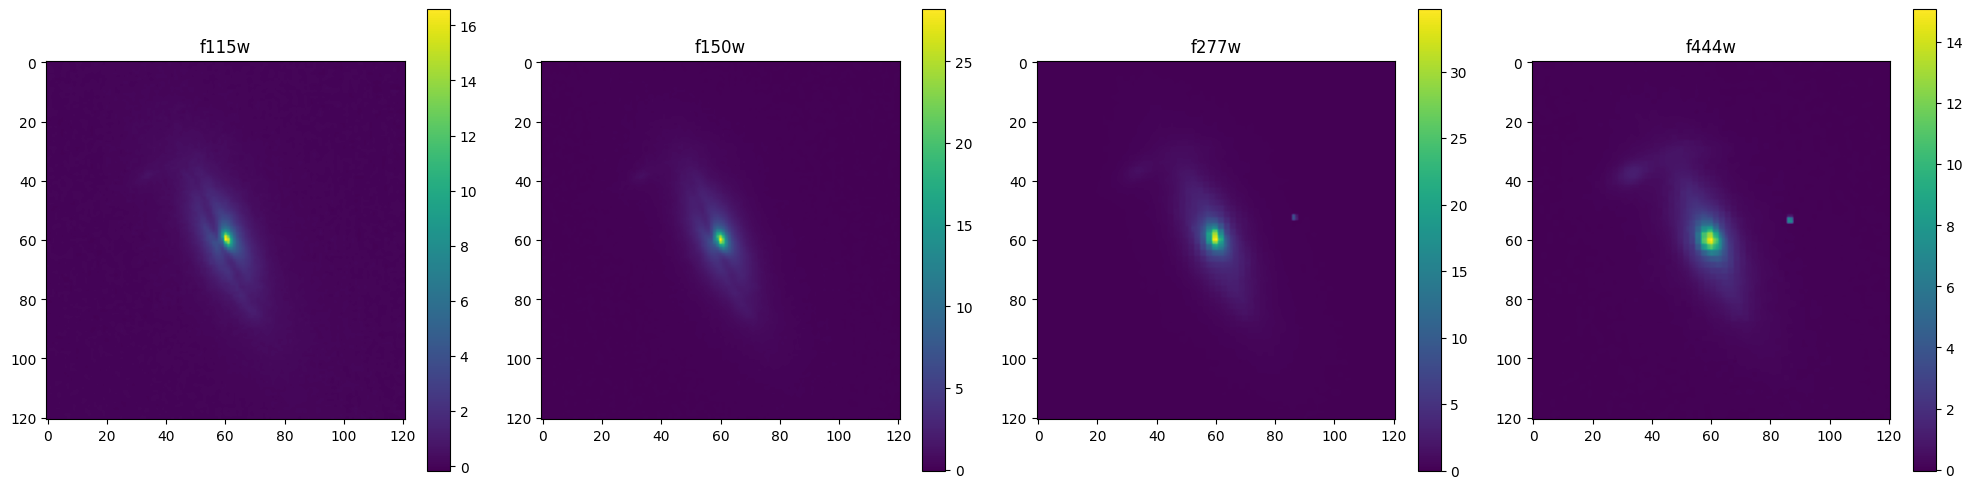

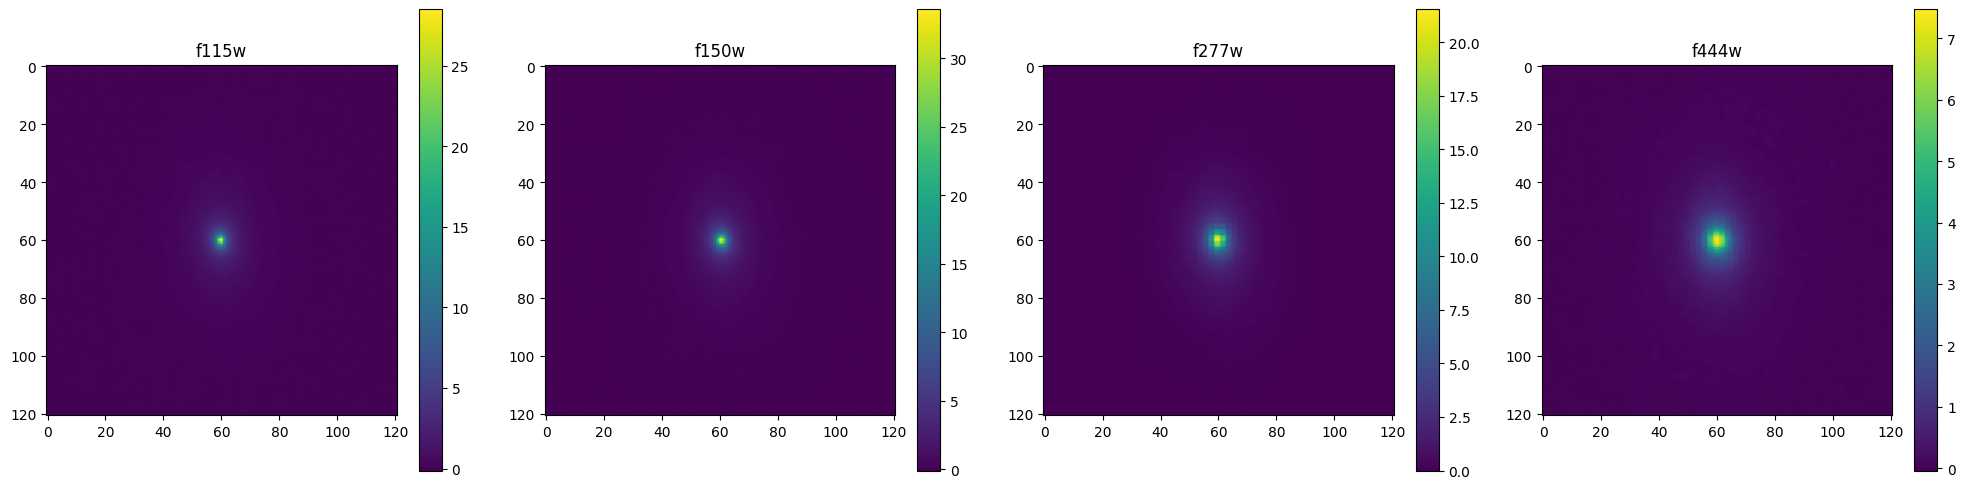

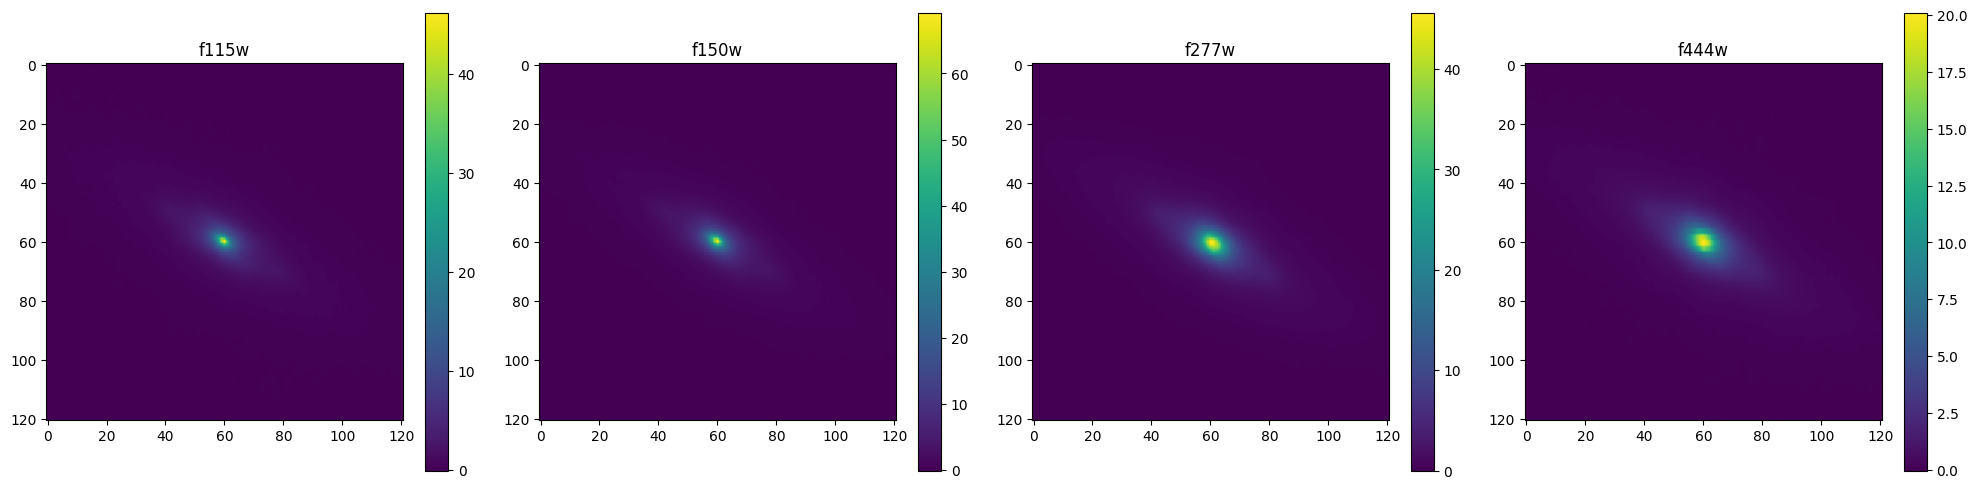

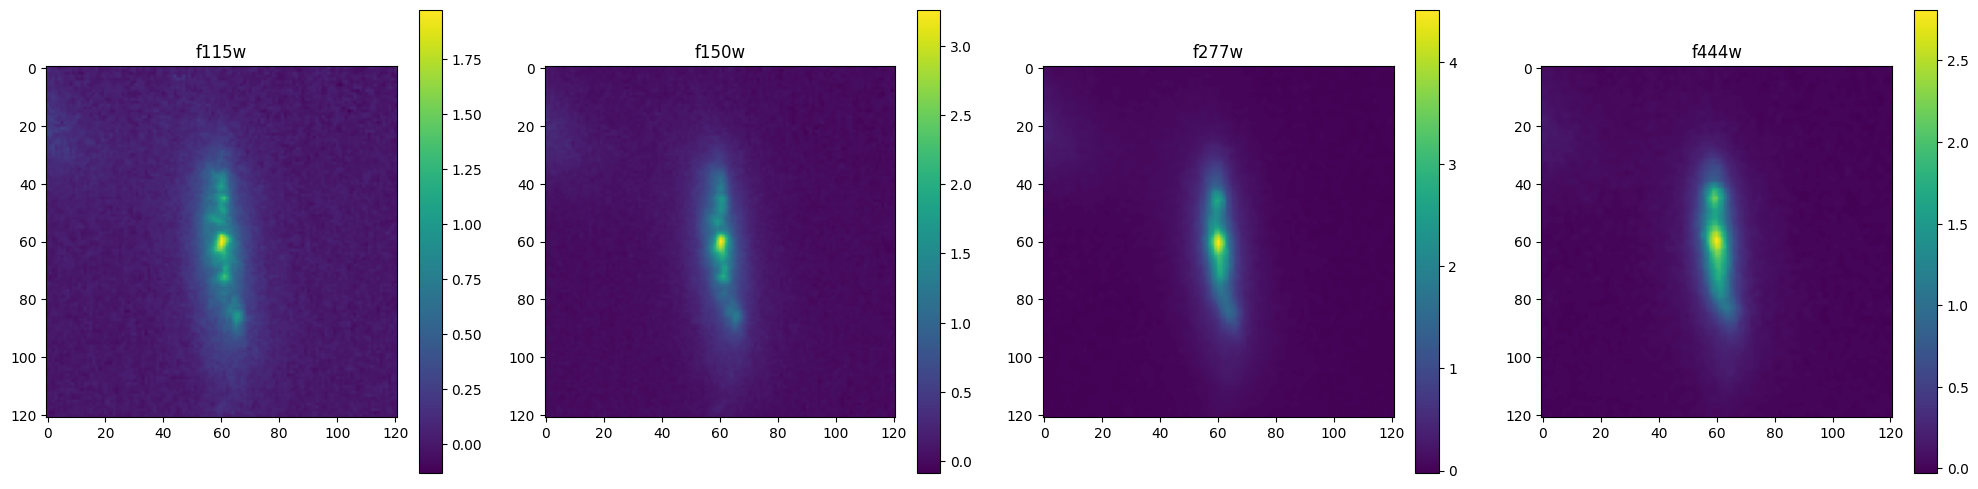

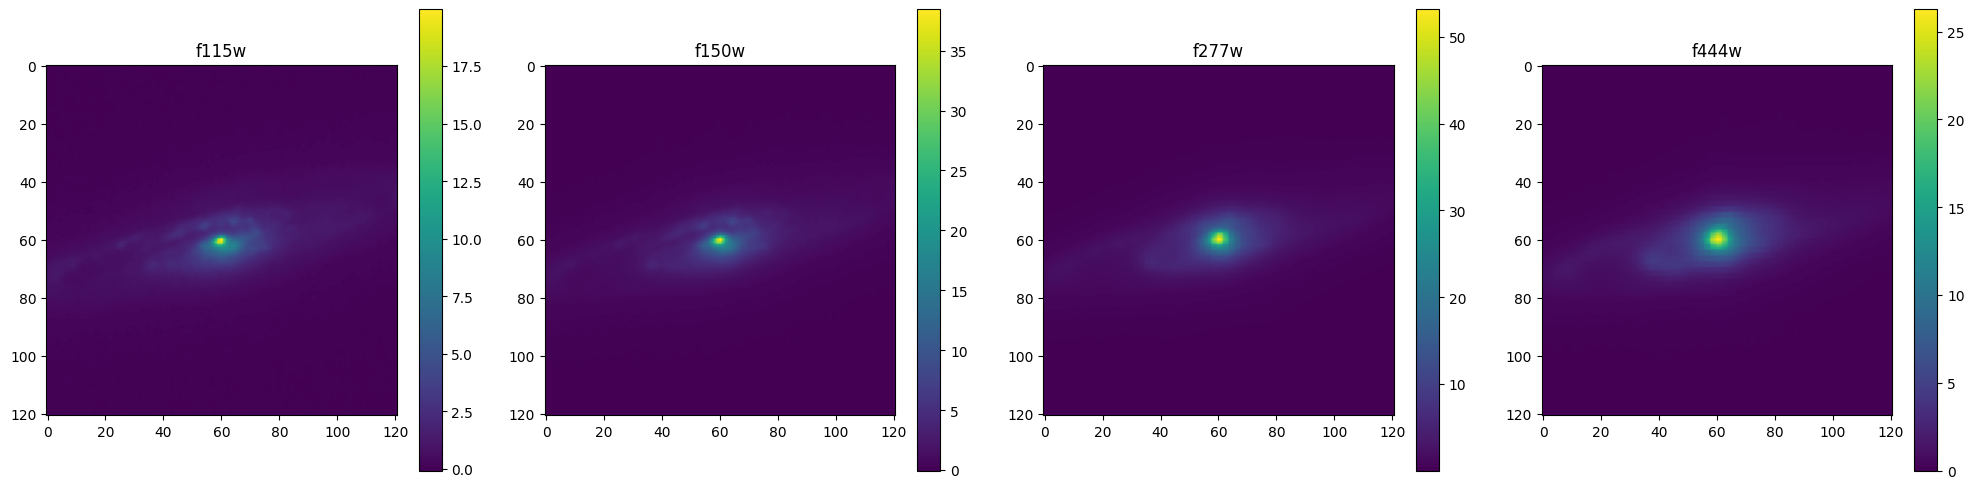

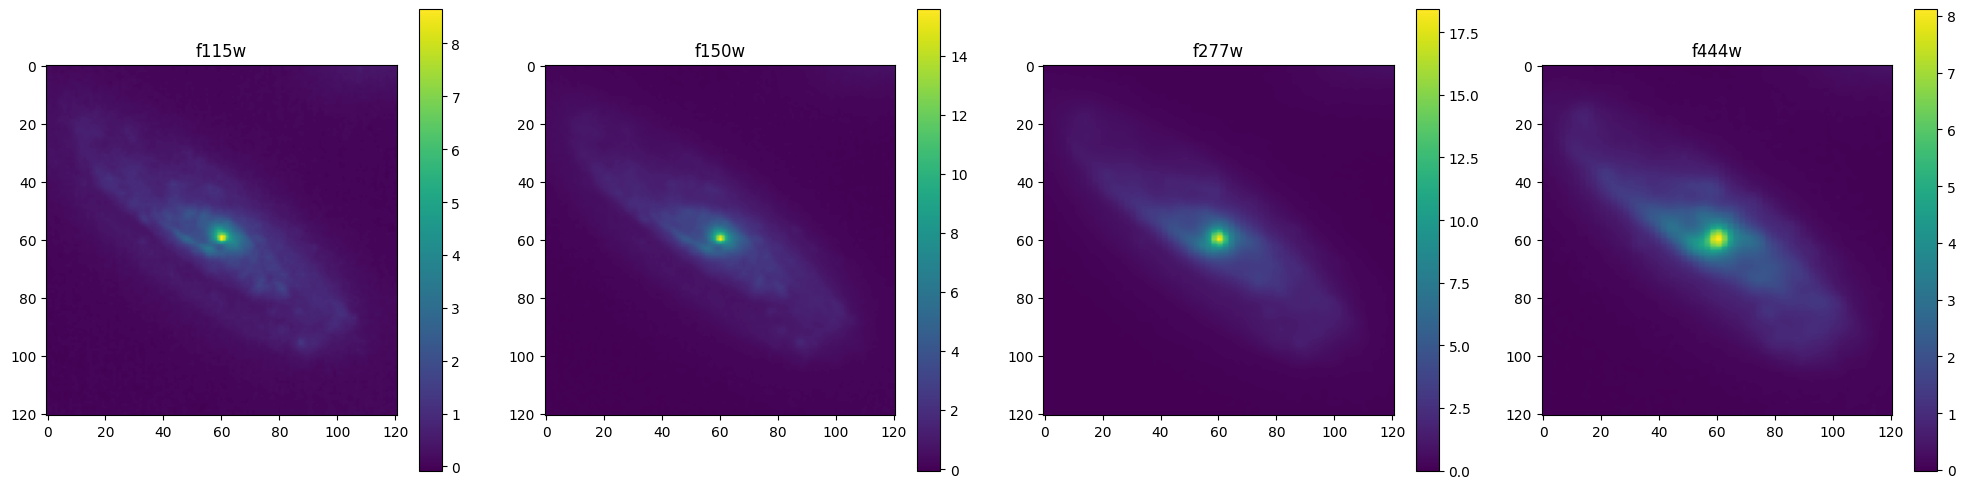

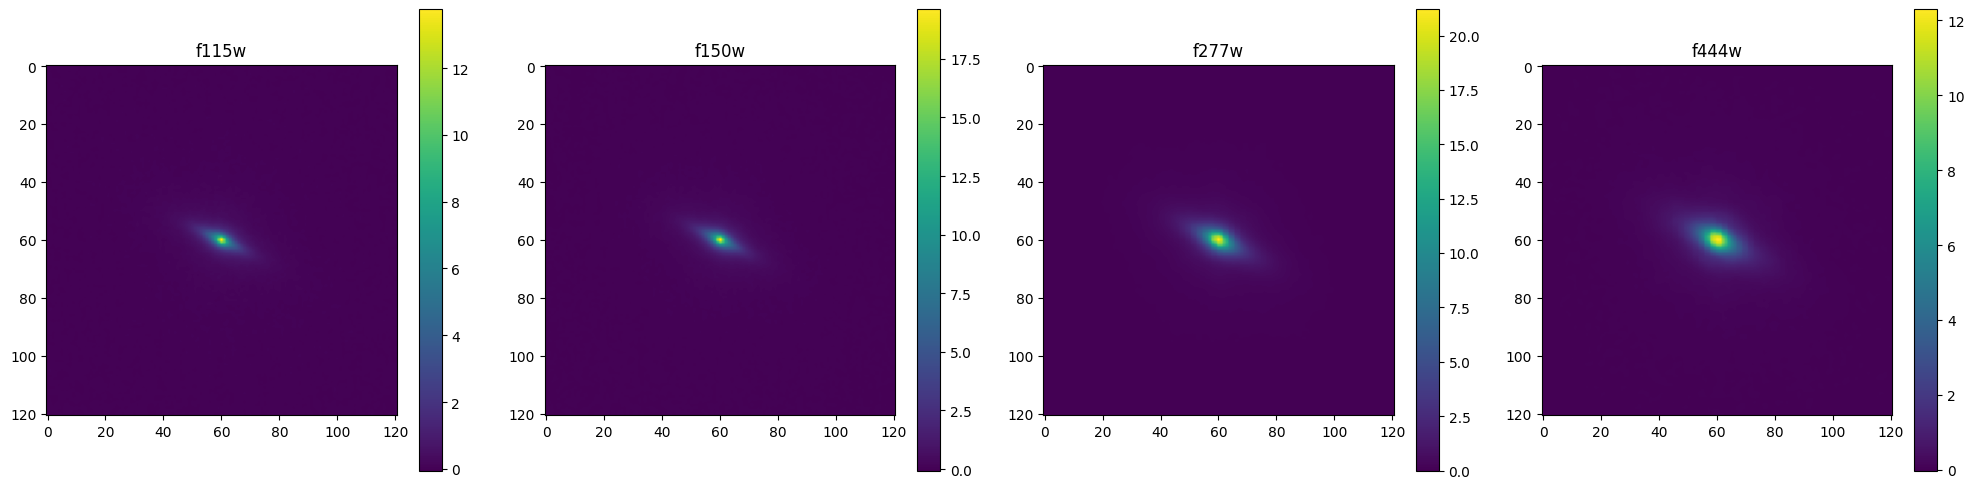

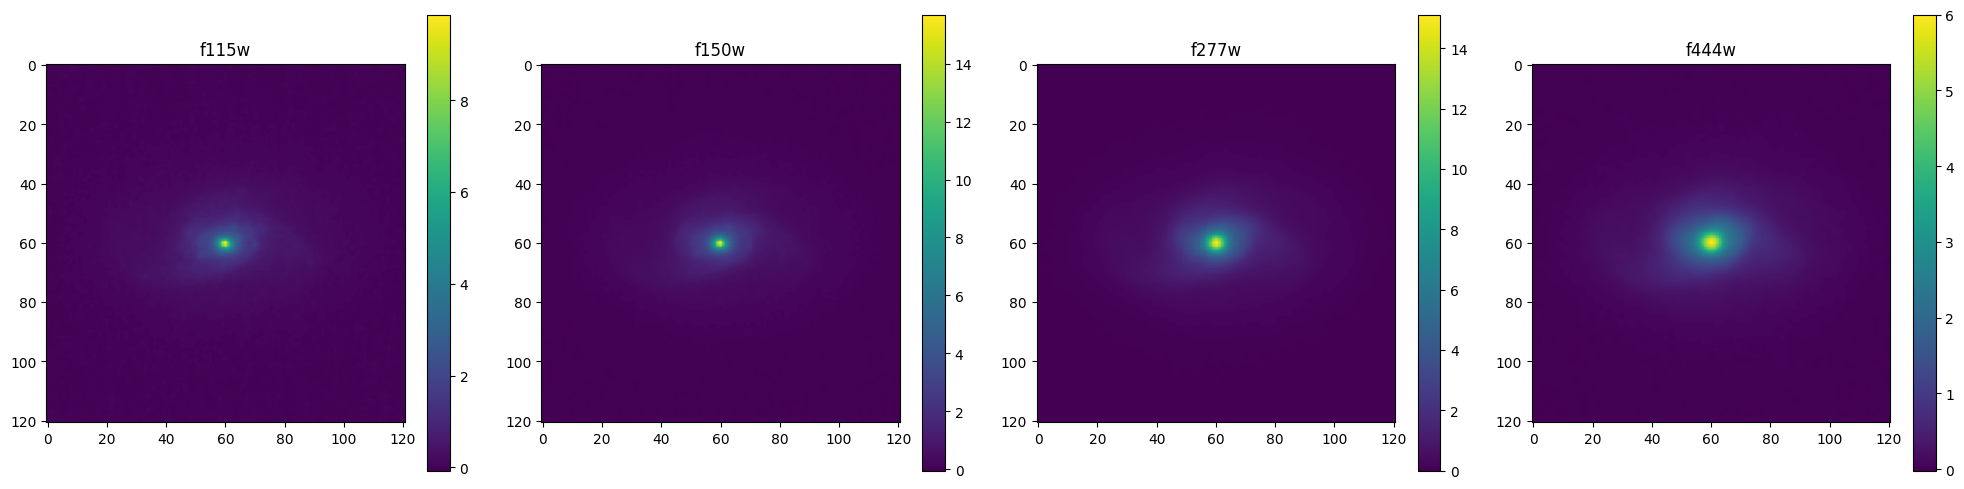

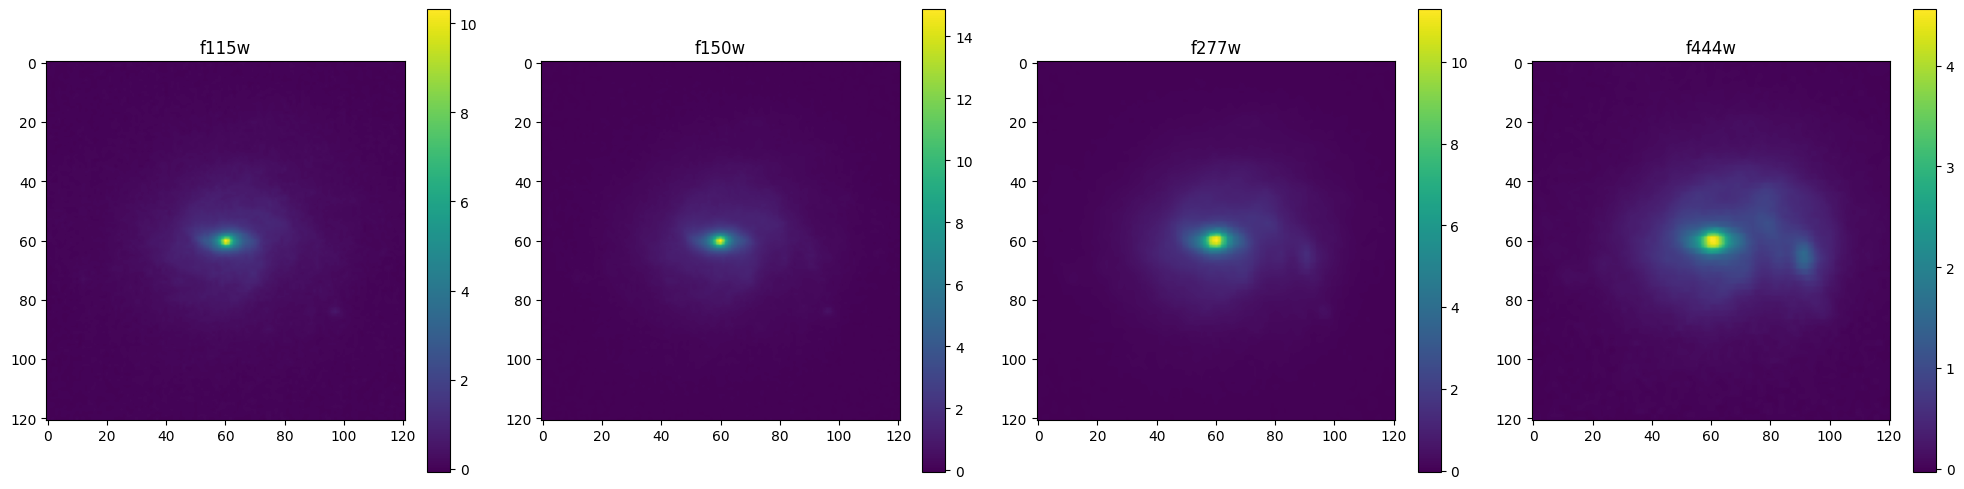

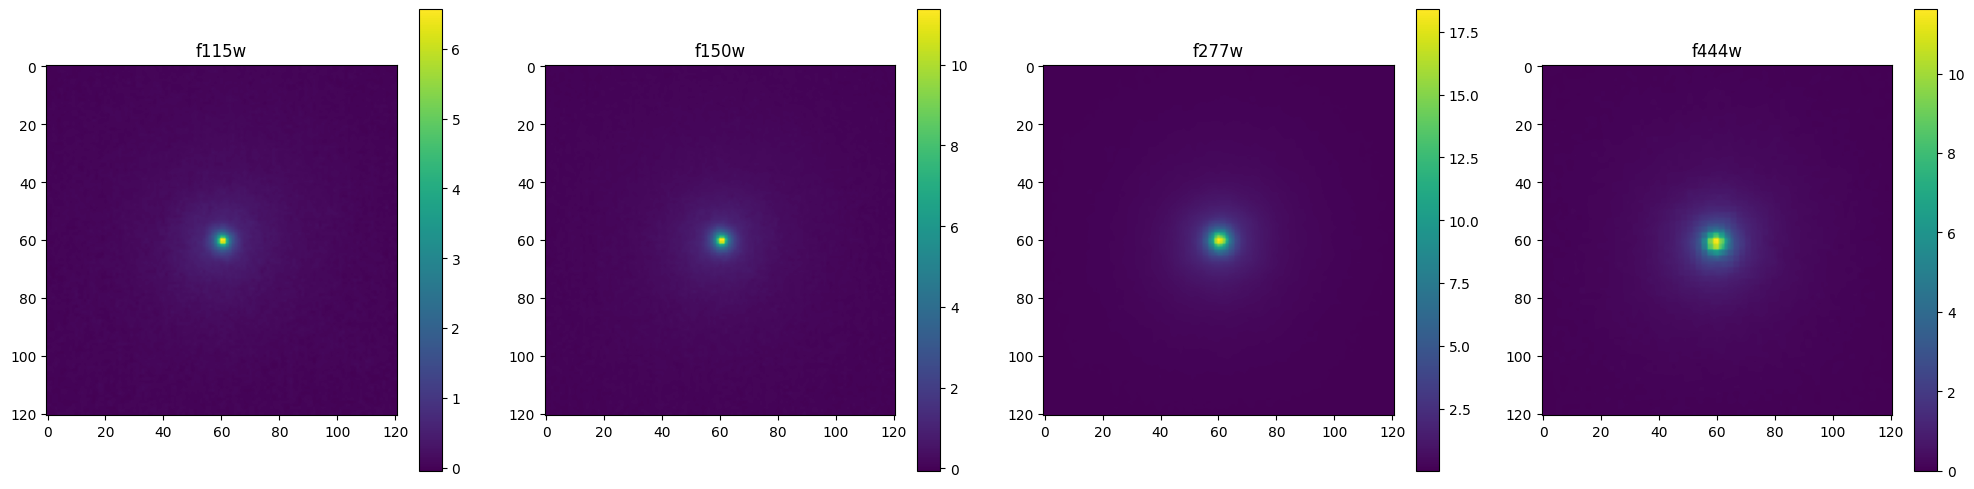

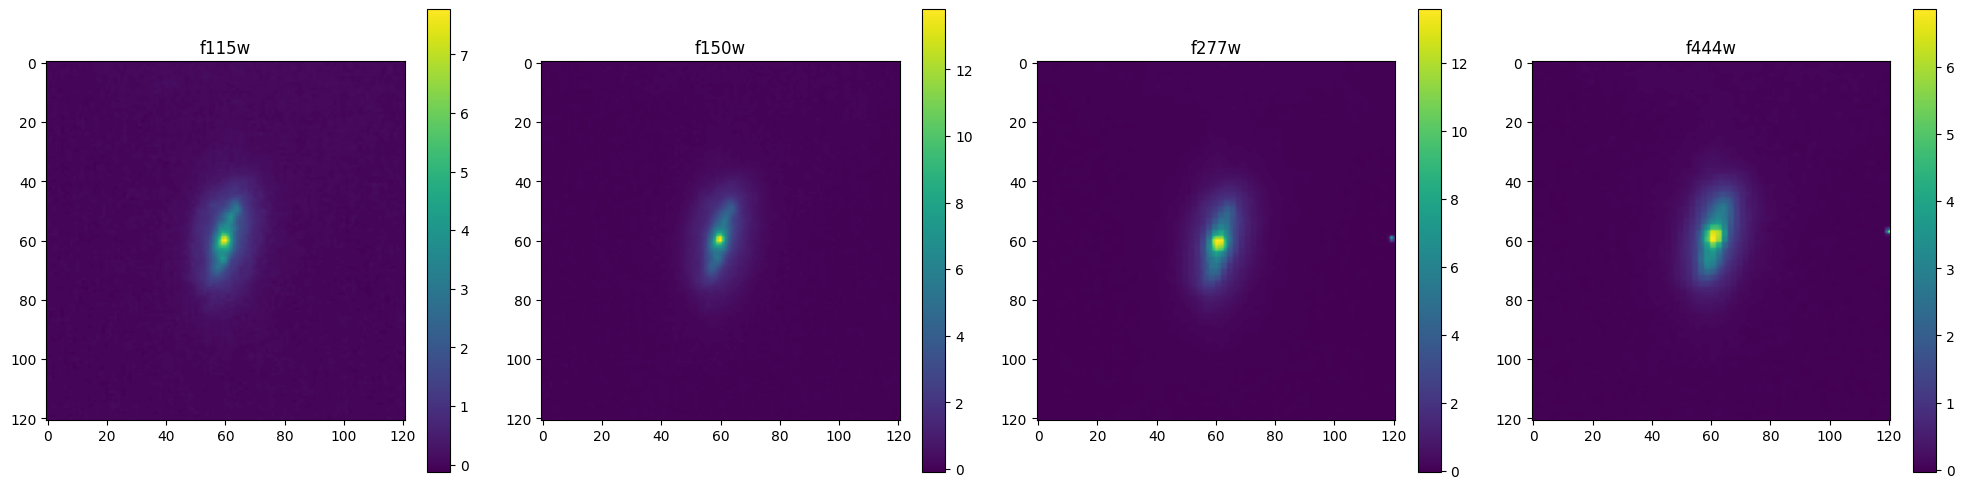

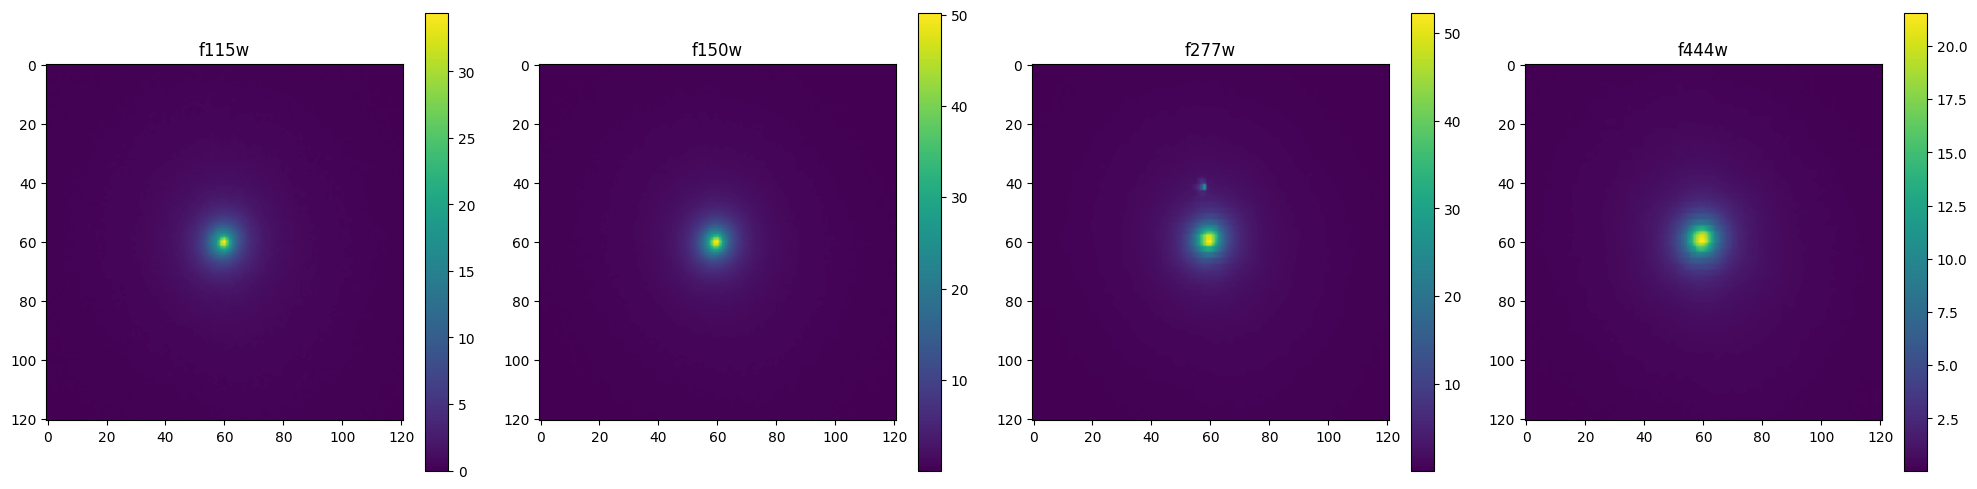

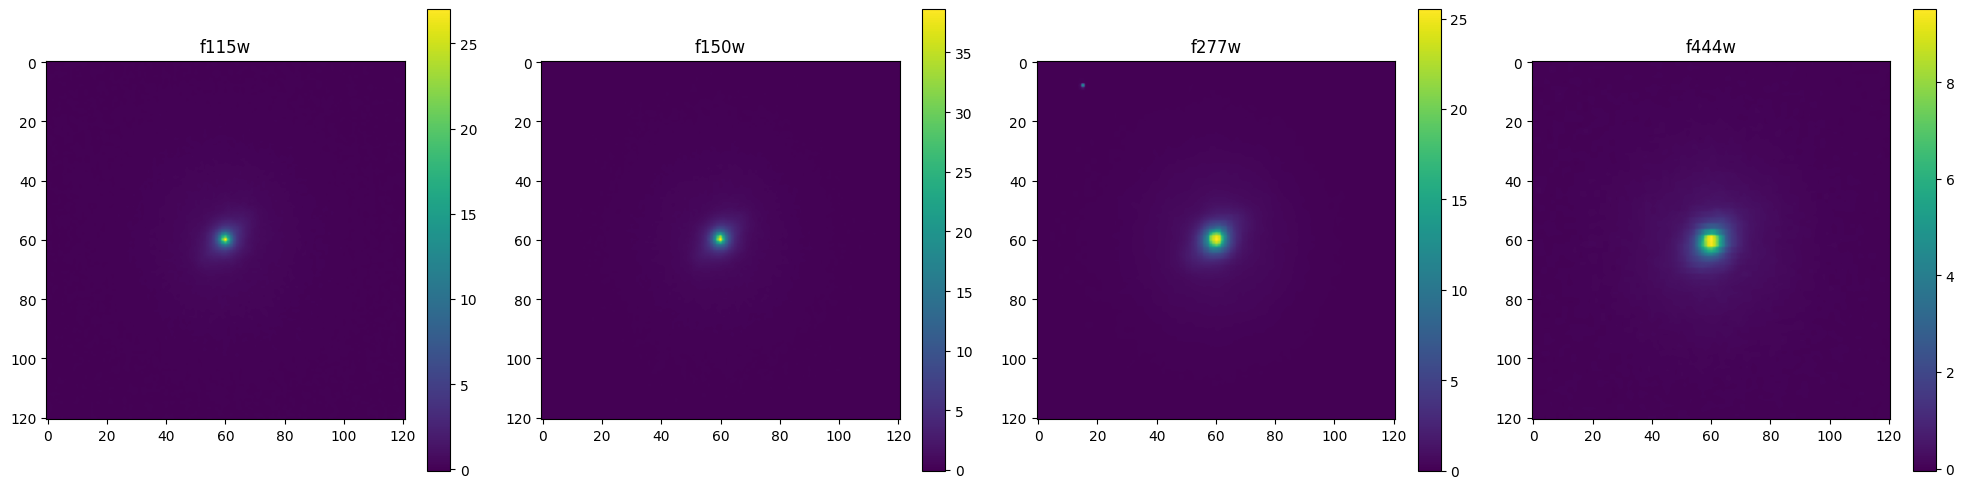

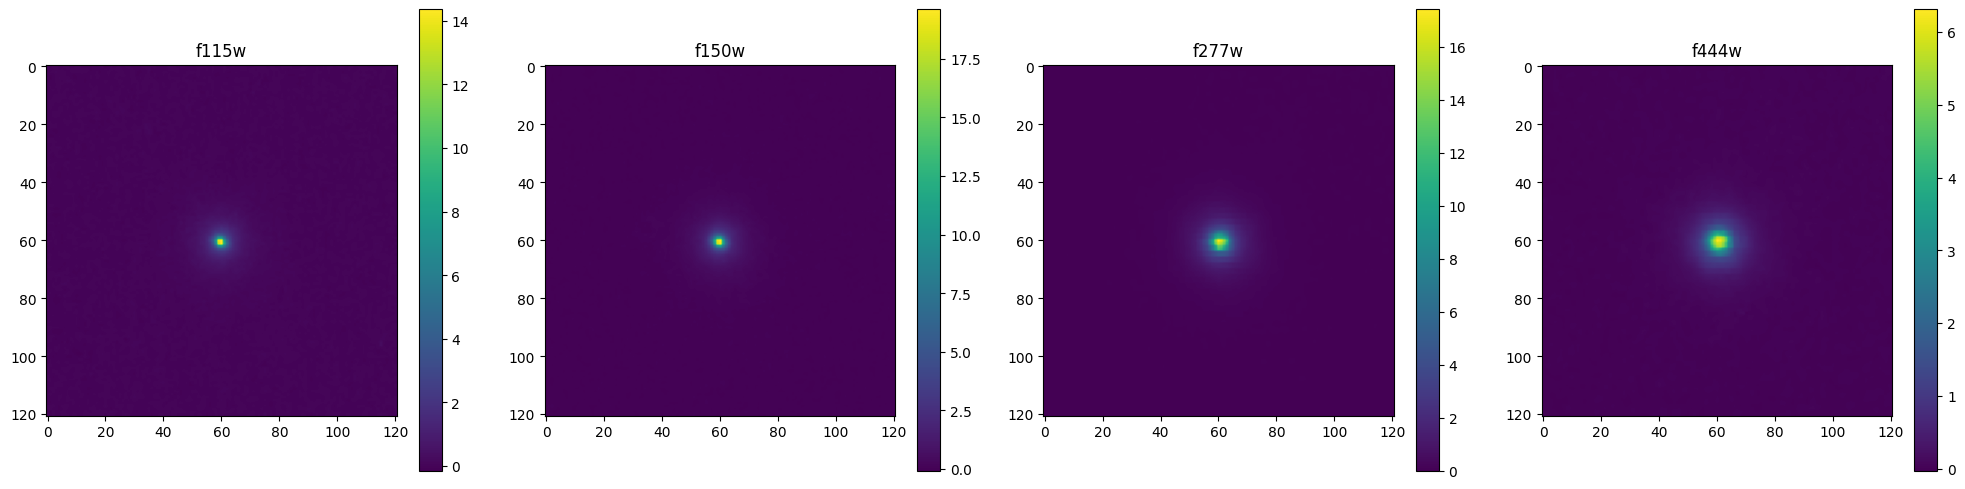

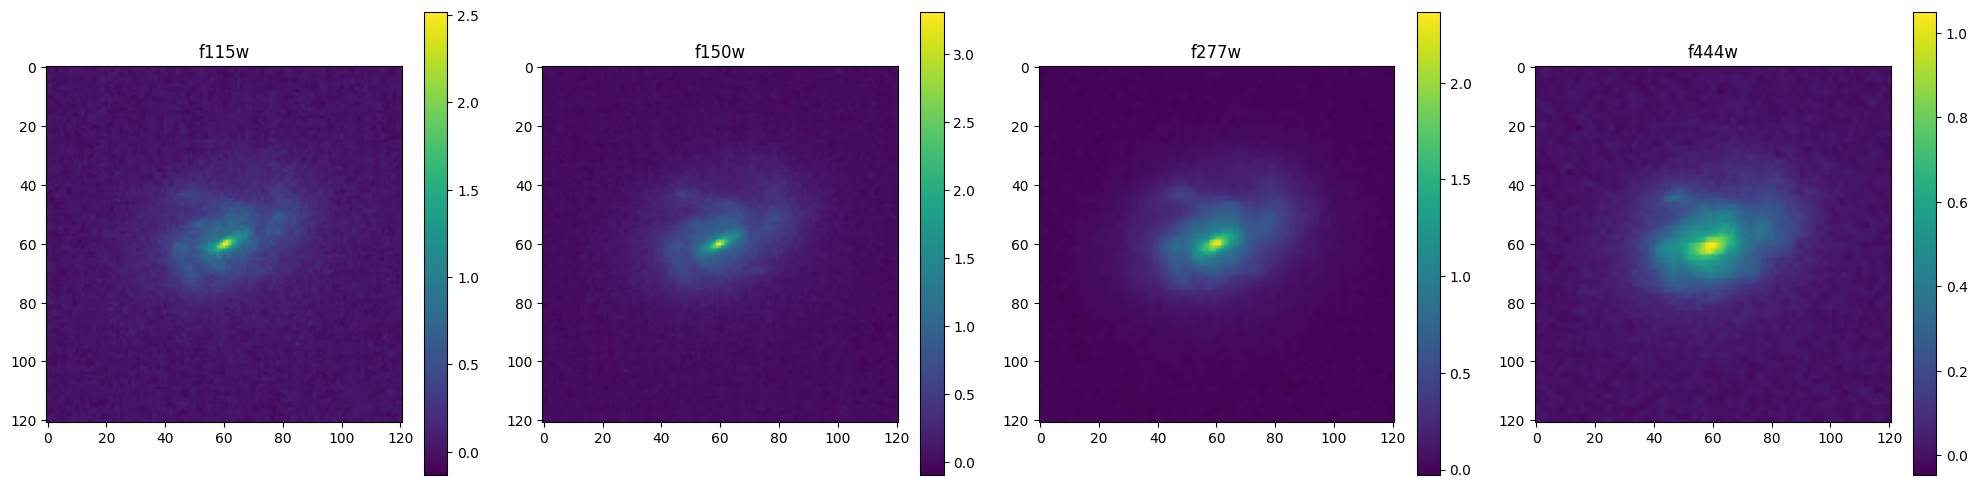

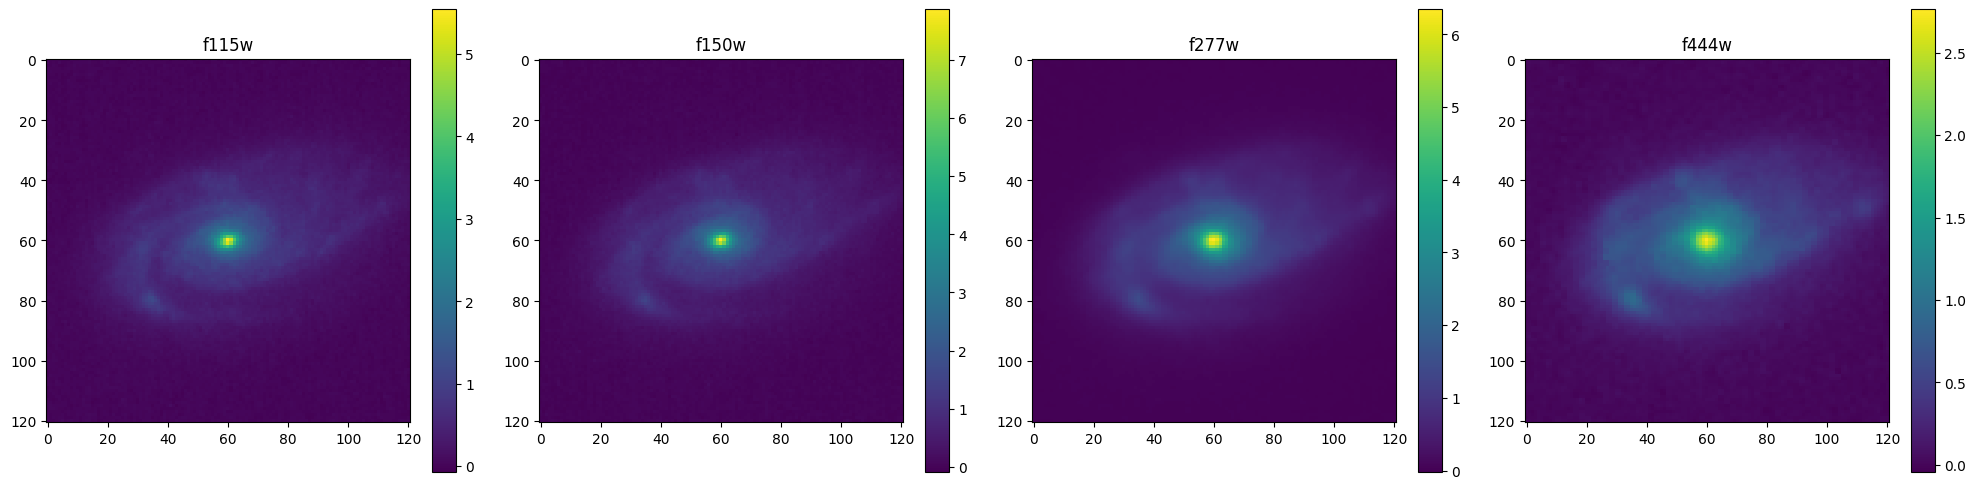

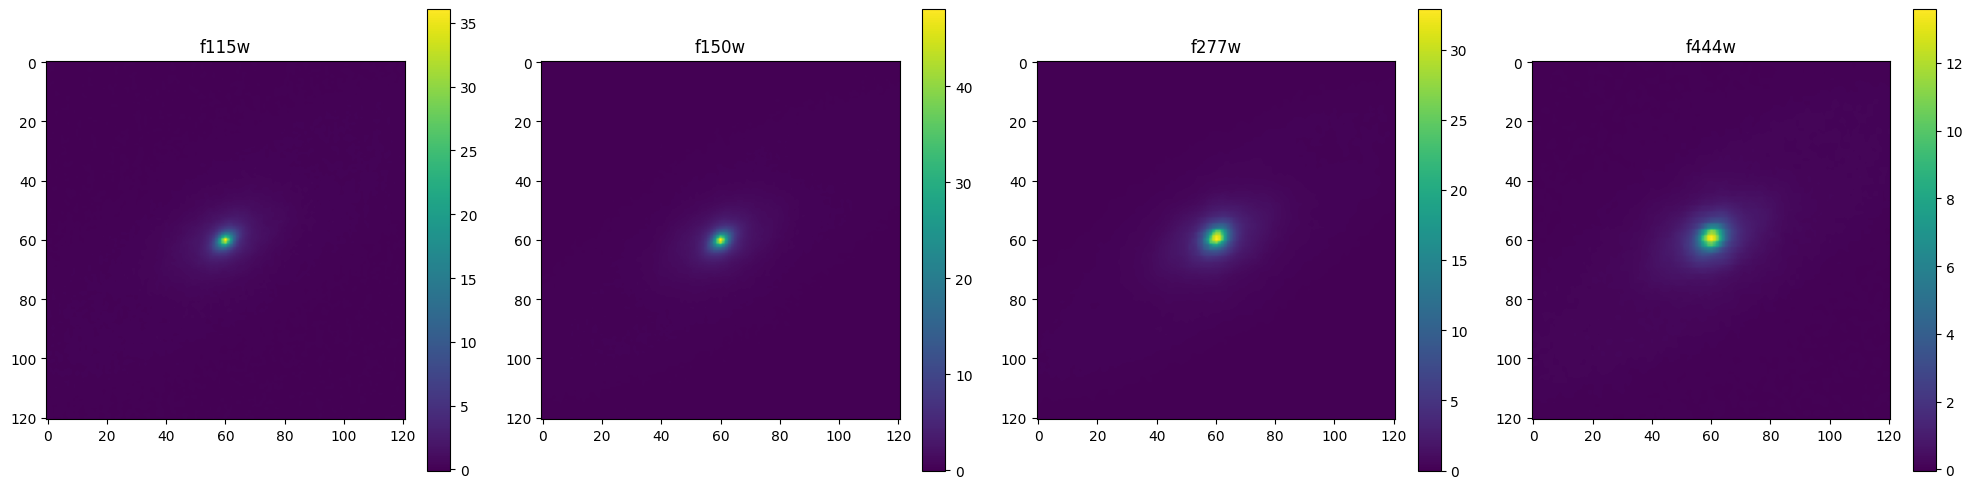

In [12]:
import matplotlib.pyplot as plt

for id in processed_catalog['id'][:20]:
    fig, ax = plt.subplots(1, 4, figsize=(20, 5))
    output_filename = f"COSMOSWeb_galaxy_{id}_image.fits"
    image_file = os.path.join(output_file_directory, output_filename)

    with fits.open(image_file) as hdul:
        for i in range(4):
            im = ax[i].imshow(hdul[i+1].data)
            ax[i].set_title(band_list[i])
            plt.colorbar(im, ax=ax[i])

    plt.tight_layout()
    plt.show()